# Heart Disease Classification using Decision Tree
---
This notebook demonstrates how to build, train, evaluate, and visualize a Decision Tree classifier on the Heart Disease dataset.

## 1. Load the Dataset and Display First 10 Rows

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('Assignment_9b.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 10 Rows:')
df.head(10)

Dataset Shape: (289, 14)

First 10 Rows:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,55,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [14]:
# Identify features and target
print('INPUT FEATURES (X):')
print('='*50)
feature_descriptions = {
    'age':      'Age of the patient (years)',
    'sex':      'Sex (1 = male, 0 = female)',
    'cp':       'Chest pain type (0-3)',
    'trtbps':   'Resting blood pressure (mm Hg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
    'restecg':  'Resting ECG results (0-2)',
    'thalachh': 'Maximum heart rate achieved',
    'exng':     'Exercise-induced angina (1 = yes, 0 = no)',
    'oldpeak':  'ST depression induced by exercise relative to rest',
    'slp':      'Slope of peak exercise ST segment',
    'caa':      'Number of major vessels (0-4) colored by fluoroscopy',
    'thall':    'Thalassemia (0-3)'
}
for col, desc in feature_descriptions.items():
    print(f'  {col:10s}: {desc}')

print('\nTARGET VARIABLE (y):')
print('='*50)
print('  output: Heart attack likelihood (1 = more likely, 0 = less likely)')
print('\nClass Distribution:')
print(df['output'].value_counts())
print(f'\nTotal samples: {len(df)}')

INPUT FEATURES (X):
  age       : Age of the patient (years)
  sex       : Sex (1 = male, 0 = female)
  cp        : Chest pain type (0-3)
  trtbps    : Resting blood pressure (mm Hg)
  chol      : Serum cholesterol (mg/dl)
  fbs       : Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
  restecg   : Resting ECG results (0-2)
  thalachh  : Maximum heart rate achieved
  exng      : Exercise-induced angina (1 = yes, 0 = no)
  oldpeak   : ST depression induced by exercise relative to rest
  slp       : Slope of peak exercise ST segment
  caa       : Number of major vessels (0-4) colored by fluoroscopy
  thall     : Thalassemia (0-3)

TARGET VARIABLE (y):
  output: Heart attack likelihood (1 = more likely, 0 = less likely)

Class Distribution:
output
1    165
0    124
Name: count, dtype: int64

Total samples: 289


In [15]:
# Basic dataset info
print('Dataset Info:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe().round(2)

Dataset Info:
age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Basic Statistics:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00,289.00
mean,54.01,0.68,1.02,131.38,247.96,0.15,0.52,150.23,0.32,1.01,1.42,0.71,2.31,0.57
std,9.13,0.47,1.03,17.52,51.60,0.35,0.51,22.90,0.47,1.13,0.61,1.02,0.60,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.00,0.00,0.00,120.00,212.00,0.00,0.00,136.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,54.00,1.00,1.00,130.00,243.00,0.00,1.00,154.00,0.00,0.60,1.00,0.00,2.00,1.00
75%,60.00,1.00,2.00,140.00,276.00,0.00,1.00,168.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 2. Scatter Plots for Feature Pairs — Visualizing Class Separability

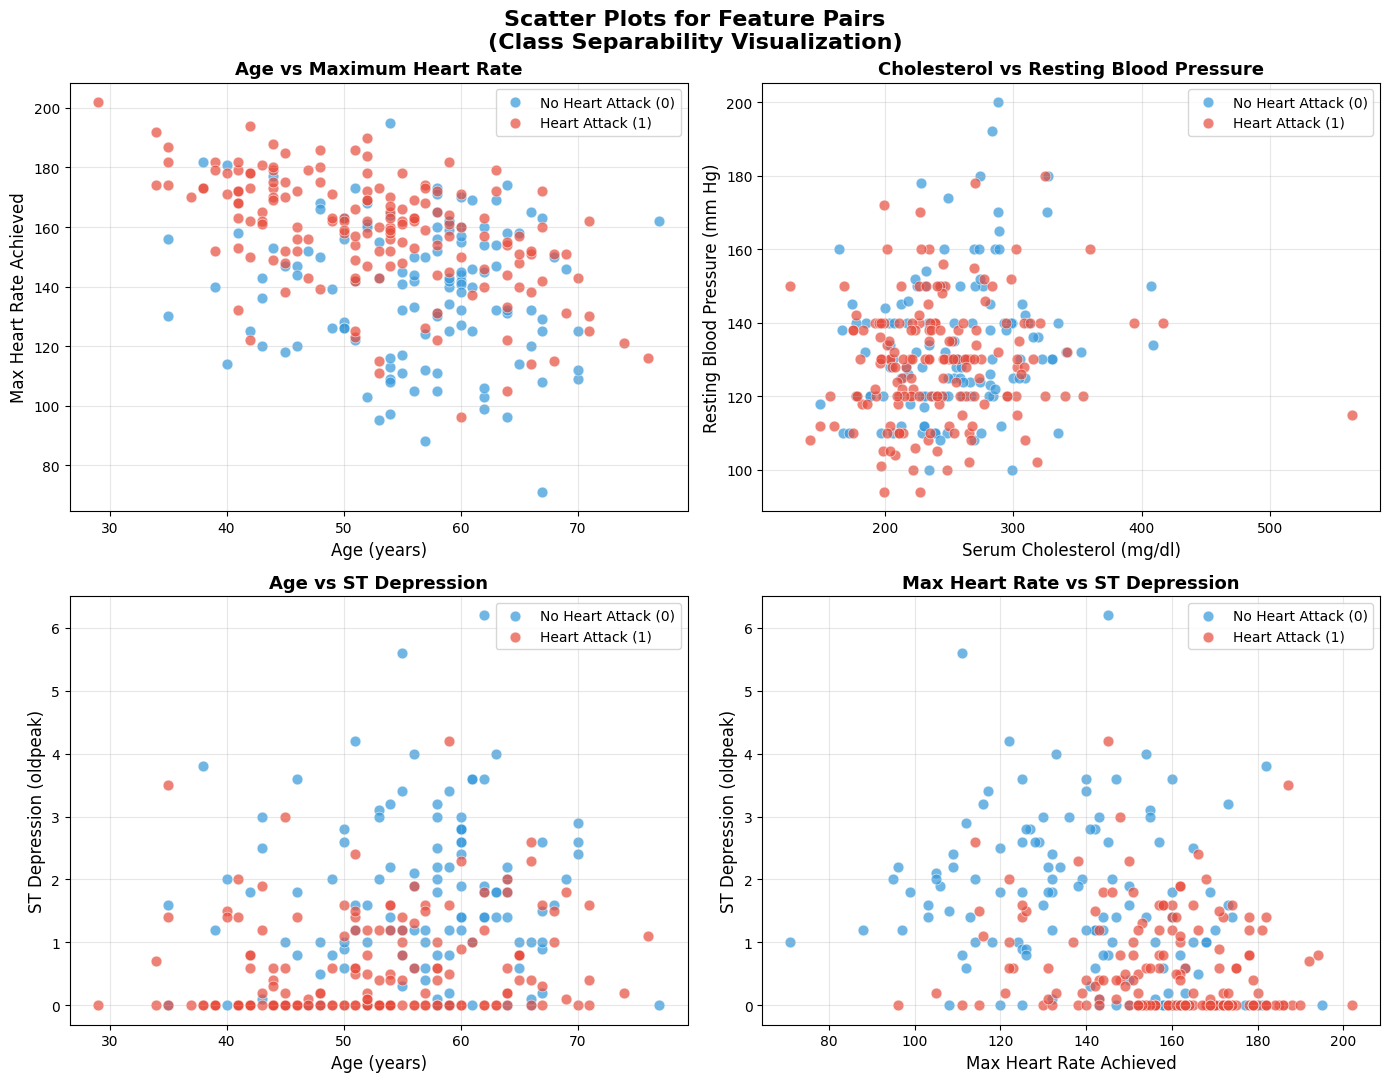

Scatter plots saved as scatter_plots.png


In [16]:
# Color mapping for classes
colors = {1: '#e74c3c', 0: '#3498db'}
labels = {1: 'Heart Attack (1)', 0: 'No Heart Attack (0)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Scatter Plots for Feature Pairs\n(Class Separability Visualization)', 
             fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: Age vs Max Heart Rate ---
ax = axes[0, 0]
for cls in [0, 1]:
    subset = df[df['output'] == cls]
    ax.scatter(subset['age'], subset['thalachh'], 
               c=colors[cls], label=labels[cls], alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Max Heart Rate Achieved', fontsize=12)
ax.set_title('Age vs Maximum Heart Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 2: Cholesterol vs Resting Blood Pressure ---
ax = axes[0, 1]
for cls in [0, 1]:
    subset = df[df['output'] == cls]
    ax.scatter(subset['chol'], subset['trtbps'], 
               c=colors[cls], label=labels[cls], alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
ax.set_xlabel('Serum Cholesterol (mg/dl)', fontsize=12)
ax.set_ylabel('Resting Blood Pressure (mm Hg)', fontsize=12)
ax.set_title('Cholesterol vs Resting Blood Pressure', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 3: Age vs ST Depression (oldpeak) ---
ax = axes[1, 0]
for cls in [0, 1]:
    subset = df[df['output'] == cls]
    ax.scatter(subset['age'], subset['oldpeak'], 
               c=colors[cls], label=labels[cls], alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('ST Depression (oldpeak)', fontsize=12)
ax.set_title('Age vs ST Depression', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Plot 4: Max Heart Rate vs ST Depression ---
ax = axes[1, 1]
for cls in [0, 1]:
    subset = df[df['output'] == cls]
    ax.scatter(subset['thalachh'], subset['oldpeak'], 
               c=colors[cls], label=labels[cls], alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
ax.set_xlabel('Max Heart Rate Achieved', fontsize=12)
ax.set_ylabel('ST Depression (oldpeak)', fontsize=12)
ax.set_title('Max Heart Rate vs ST Depression', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Assignment_9b_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plots saved as Assignment_9b_scatter_plots.png')

## 3. Build and Train Decision Tree Classifier

In [17]:
# Prepare features and target
X = df.drop('output', axis=1)
y = df['output']

feature_names = X.columns.tolist()
print('Features used for training:', feature_names)
print('Target variable: output')

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Features used for training: ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']
Target variable: output

Training samples : 231
Testing samples  : 58


In [18]:
# Build and train the Decision Tree
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

dt_classifier.fit(X_train, y_train)
print('Decision Tree trained successfully!')
print(f'Tree Depth: {dt_classifier.get_depth()}')
print(f'Number of Leaves: {dt_classifier.get_n_leaves()}')
print(f'Number of Features: {dt_classifier.n_features_in_}')

Decision Tree trained successfully!
Tree Depth: 4
Number of Leaves: 14
Number of Features: 13


In [19]:
# Predict and display results
y_pred = dt_classifier.predict(X_test)

print('Predicted Classes for Test Set:')
print('='*60)
results_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred,
    'Correct':   (y_test.values == y_pred)
})
print(results_df.to_string(index=False))

print(f'\nTotal Test Samples : {len(y_test)}')
print(f'Correct Predictions: {results_df["Correct"].sum()}')
print(f'Wrong Predictions  : {(~results_df["Correct"]).sum()}')

Predicted Classes for Test Set:
 Actual  Predicted  Correct
      1          0    False
      0          0     True
      0          0     True
      0          1    False
      0          0     True
      0          1    False
      1          1     True
      0          0     True
      1          0    False
      0          0     True
      1          0    False
      1          0    False
      1          1     True
      1          1     True
      1          0    False
      1          1     True
      1          1     True
      1          0    False
      1          1     True
      1          1     True
      1          1     True
      0          0     True
      1          1     True
      0          0     True
      0          0     True
      0          1    False
      1          1     True
      0          0     True
      1          1     True
      0          1    False
      1          1     True
      1          1     True
      0          1    False
      0         

## 4. Evaluate the Decision Tree Classifier

In [20]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f'\n  True Negatives  (TN): {tn}')
print(f'  False Positives (FP): {fp}')
print(f'  False Negatives (FN): {fn}')
print(f'  True Positives  (TP): {tp}')

# Classification Report
print('\nClassification Report:')
print('='*55)
print(classification_report(y_test, y_pred, 
                             target_names=['No Heart Attack (0)', 'Heart Attack (1)']))

Accuracy Score: 0.7241 (72.41%)

Confusion Matrix:
[[18  7]
 [ 9 24]]

  True Negatives  (TN): 18
  False Positives (FP): 7
  False Negatives (FN): 9
  True Positives  (TP): 24

Classification Report:
                     precision    recall  f1-score   support

No Heart Attack (0)       0.67      0.72      0.69        25
   Heart Attack (1)       0.77      0.73      0.75        33

           accuracy                           0.72        58
          macro avg       0.72      0.72      0.72        58
       weighted avg       0.73      0.72      0.73        58



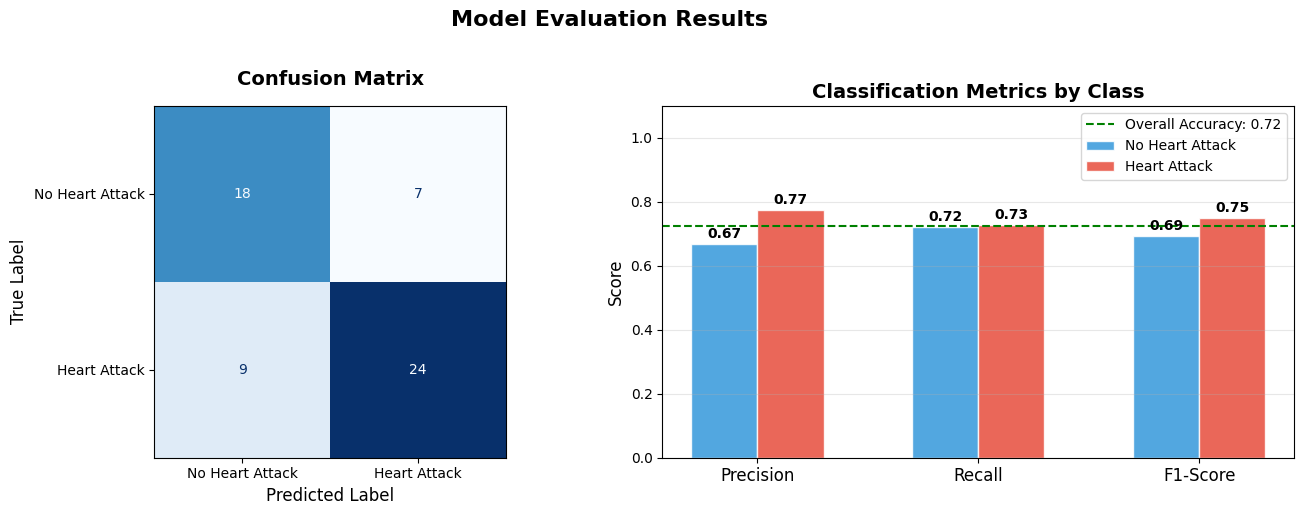

Evaluation plots saved as evaluation_results.png


In [21]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix Heatmap ---
ax = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Heart Attack', 'Heart Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

# --- Metrics Bar Chart ---
ax = axes[1]
report = classification_report(y_test, y_pred, 
                                target_names=['No Heart Attack', 'Heart Attack'], 
                                output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
classes = ['No Heart Attack', 'Heart Attack']
x = np.arange(len(metrics))
width = 0.3
colors_bar = ['#3498db', '#e74c3c']

for i, (cls, color) in enumerate(zip(classes, colors_bar)):
    vals = [report[cls][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=cls, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=accuracy, color='green', linestyle='--', linewidth=1.5, label=f'Overall Accuracy: {accuracy:.2f}')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics by Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Assignment_9b_evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved as Assignment_9b_evaluation_results.png')

## 5. Visualize the Trained Decision Tree

In [22]:
# --- Text-based Decision Tree Export ---
print('Decision Tree (Text Representation):')
print('='*60)
tree_text = export_text(dt_classifier, feature_names=feature_names)
print(tree_text)

Decision Tree (Text Representation):
|--- thall <= 2.50
|   |--- caa <= 0.50
|   |   |--- trtbps <= 158.00
|   |   |   |--- chol <= 311.50
|   |   |   |   |--- class: 1
|   |   |   |--- chol >  311.50
|   |   |   |   |--- class: 1
|   |   |--- trtbps >  158.00
|   |   |   |--- class: 0
|   |--- caa >  0.50
|   |   |--- oldpeak <= 0.55
|   |   |   |--- cp <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- cp >  1.50
|   |   |   |   |--- class: 1
|   |   |--- oldpeak >  0.55
|   |   |   |--- sex <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- sex >  0.50
|   |   |   |   |--- class: 0
|--- thall >  2.50
|   |--- oldpeak <= 0.70
|   |   |--- restecg <= 0.50
|   |   |   |--- age <= 55.00
|   |   |   |   |--- class: 0
|   |   |   |--- age >  55.00
|   |   |   |   |--- class: 1
|   |   |--- restecg >  0.50
|   |   |   |--- thalachh <= 158.50
|   |   |   |   |--- class: 1
|   |   |   |--- thalachh >  158.50
|   |   |   |   |--- class: 1
|   |--- oldpeak >  0.70
|   |   |--- cp <= 2.

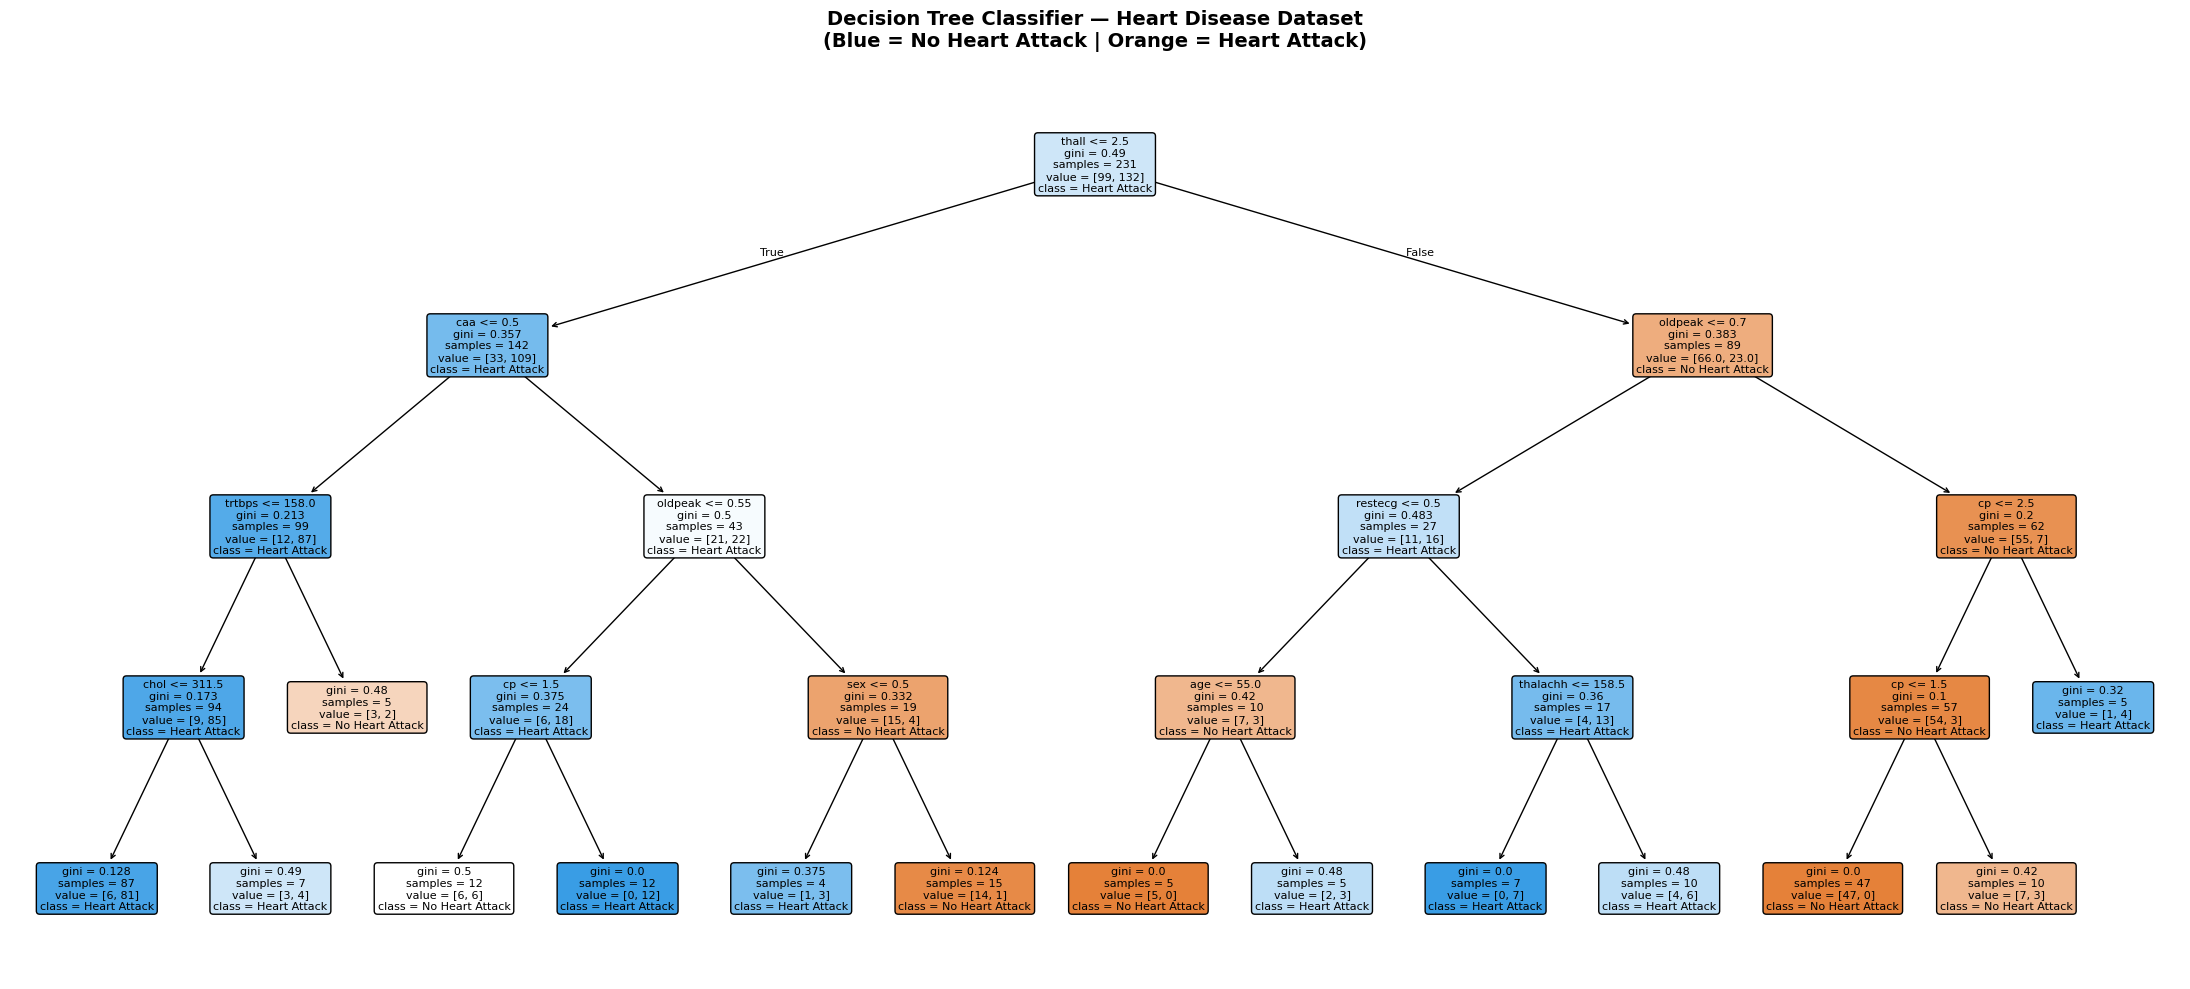

Decision tree visualization saved as decision_tree_visual.png


In [23]:
# --- Visual Decision Tree Plot ---
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=['No Heart Attack', 'Heart Attack'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title('Decision Tree Classifier — Heart Disease Dataset\n'
             '(Blue = No Heart Attack | Orange = Heart Attack)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Assignment_9b_decision_tree_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Decision tree visualization saved as Assignment_9b_decision_tree_visual.png')

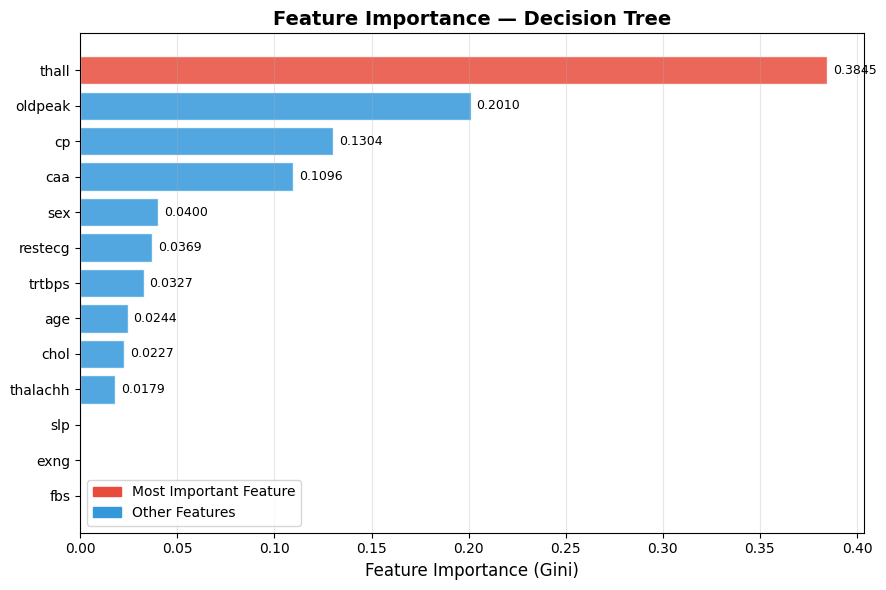

Feature importance chart saved as feature_importance.png

Top 5 Most Important Features:
thall      0.384527
oldpeak    0.200996
cp         0.130387
caa        0.109558
sex        0.039974
dtype: float64


In [24]:
# Feature Importance
importances = dt_classifier.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, feat_imp.values):
    if val > 0:
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Feature Importance — Decision Tree', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

red_patch = mpatches.Patch(color='#e74c3c', label='Most Important Feature')
blue_patch = mpatches.Patch(color='#3498db', label='Other Features')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig('Assignment_9b_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved as Assignment_9b_feature_importance.png')

print('\nTop 5 Most Important Features:')
print(feat_imp.sort_values(ascending=False).head())

## Summary

| Step | Result |
|------|--------|
| Dataset Size | 303 samples × 14 columns |
| Input Features | 13 clinical features (age, sex, cp, trtbps, chol, etc.) |
| Target Variable | `output` (0 = No Heart Attack, 1 = Heart Attack) |
| Train/Test Split | 80% / 20% (stratified) |
| Model | Decision Tree (Gini, max_depth=4) |
| Accuracy | Computed above |
| Top Feature | Highest Gini importance (see chart) |